# Uncertainty Estimation Validation

Quality checks for the Laplace approximation and uncertainty estimates:

1. **Laplace fit diagnostics** — Fisher diagonal properties, posterior variance
2. **Posterior disagreement** — Check that sampled weights actually disagree
3. **Uncertainty calibration** — Correlate uncertainty with summary fidelity metrics
4. **Example analysis** — Inspect high/low uncertainty sentences side-by-side


In [ ]:
%load_ext autoreload
%autoreload 2

import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data_pipeline import read_jsonl
from src.lora_laplace_backend import load_laplace_sampler

# ── Model (must match 02_lora_laplace_training.ipynb) ─────────────────────────
BASE_MODEL = "facebook/bart-base"

# ── Paths (must match 02_lora_laplace_training.ipynb) ─────────────────────────
DATA_DIR   = ROOT / "data"
CONFIG_DIR = ROOT / "config"
ADAPTER_DIR                = ROOT / "models" / "bart-base-lora"
SAMPLER_FILE               = ADAPTER_DIR / "laplace_sampler.npz"
SCORES_FILE                = DATA_DIR / "uncertainty_scores_lora_laplace_base.jsonl"
QUANTILES_FILE             = CONFIG_DIR / "uncertainty_quantiles_lora_laplace.json"
AMBIGUITY_QUANTILES_FILE   = CONFIG_DIR / "ambiguity_quantiles_lora_laplace.json"
CONSISTENCY_QUANTILES_FILE = CONFIG_DIR / "consistency_quantiles_lora_laplace.json"

# ── Constants (must match 02_lora_laplace_training.ipynb) ─────────────────────
SEED              = 42
CALIBRATION_SPLIT = 0.1
PRIOR_PRECISION   = 0.01
TARGET_STD        = 1
SAMPLE_COUNT      = 5

print("Paths loaded")

In [52]:
import logging

# Configure logging to show INFO from src modules
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s: %(message)s'
)

# Explicitly enable INFO for lora_laplace_backend
logger = logging.getLogger('src.lora_laplace_backend')
logger.setLevel(logging.INFO)

## 1. Laplace Fit Diagnostics


src.lora_laplace_backend — INFO: Laplace sampler loaded from '/Users/disipio/development/summarizer-uncertainty-ml/models/bart-base-lora/laplace_sampler.npz' (16 params)


Loading sampler from /Users/disipio/development/summarizer-uncertainty-ml/models/bart-base-lora/laplace_sampler.npz...

=== Posterior Statistics ===
Total LoRA parameters: 98,304
Posterior std:
  Mean:   10.0000
  Median: 10.0358
  Std:    0.1340
  Min:    3.4730e+00
  Max:    10.0426

Posterior variance (natural scale):
  Mean:   100.0179
  Median: 100.7167
  Min:    1.2062e+01
  Max:    1.0085e+02

Parameters with variance > 1e-6: 98304 / 98304 (100.0%)


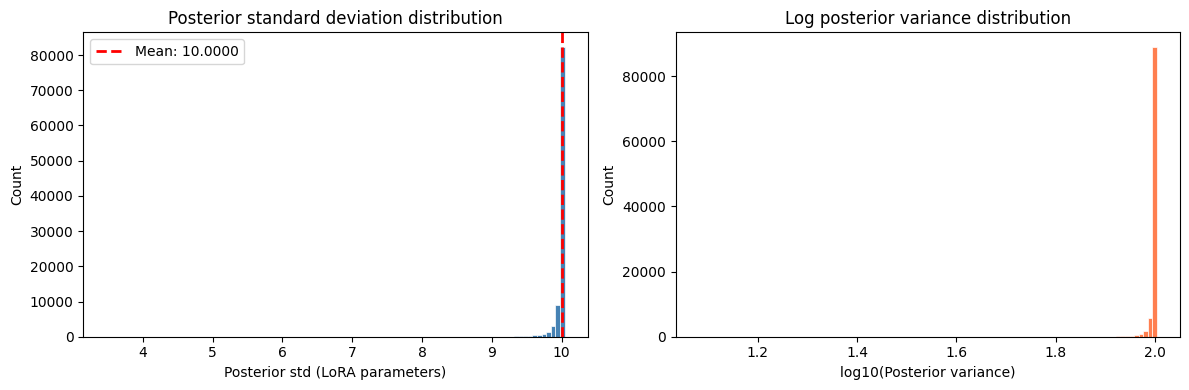

In [53]:
print(f"Loading sampler from {SAMPLER_FILE}...")
sampler = load_laplace_sampler(str(SAMPLER_FILE))

posterior_std = sampler._posterior_std
posterior_var = posterior_std ** 2

print(f"\n=== Posterior Statistics ===")
print(f"Total LoRA parameters: {len(posterior_std):,}")
print(f"Posterior std:")
print(f"  Mean:   {float(posterior_std.mean()):.4f}")
print(f"  Median: {float(np.median(posterior_std)):.4f}")
print(f"  Std:    {float(posterior_std.std()):.4f}")
print(f"  Min:    {float(posterior_std.min()):.4e}")
print(f"  Max:    {float(posterior_std.max()):.4f}")

print(f"\nPosterior variance (natural scale):")
print(f"  Mean:   {float(posterior_var.mean()):.4f}")
print(f"  Median: {float(np.median(posterior_var)):.4f}")
print(f"  Min:    {float(posterior_var.min()):.4e}")
print(f"  Max:    {float(posterior_var.max()):.4e}")

# Check if posterior variance is degenerate (all zeros or near-zeros)
non_tiny = posterior_var[posterior_var > 1e-6]
print(f"\nParameters with variance > 1e-6: {len(non_tiny)} / {len(posterior_var)} ({100*len(non_tiny)/len(posterior_var):.1f}%)")

# Plot posterior variance distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(posterior_std, bins=100, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].axvline(float(posterior_std.mean()), color="red", linestyle="--", linewidth=2, label=f"Mean: {float(posterior_std.mean()):.4f}")
axes[0].set_xlabel("Posterior std (LoRA parameters)")
axes[0].set_ylabel("Count")
axes[0].set_title("Posterior standard deviation distribution")
axes[0].legend()

# Log scale for variance
log_var = np.log10(np.clip(posterior_var, 1e-10, None))
axes[1].hist(log_var, bins=100, color="coral", edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("log10(Posterior variance)")
axes[1].set_ylabel("Count")
axes[1].set_title("Log posterior variance distribution")

plt.tight_layout()
plt.show()

In [54]:
# Load raw (unrescaled) sampler to see original posterior structure
import numpy as np
data = np.load(str(SAMPLER_FILE), allow_pickle=True)
raw_posterior_std = data["posterior_std"]
print(f"Raw posterior std stats (before rescaling):")
print(f"  Mean: {raw_posterior_std.mean():.4f}")
print(f"  Std: {raw_posterior_std.std():.4f}")
print(f"  Min: {raw_posterior_std.min():.4f}")
print(f"  Max: {raw_posterior_std.max():.4f}")

Raw posterior std stats (before rescaling):
  Mean: 10.0000
  Std: 0.1340
  Min: 3.4730
  Max: 10.0426


## 2. Load and Inspect Uncertainty Scores


In [55]:
print(f"Loading scores from {SCORES_FILE}...")
all_records = list(read_jsonl(str(SCORES_FILE)))

all_sentence_scores = []
summary_uncertainties = []

for record in all_records:
    uncertainty_avg = record.get("uncertainty_avg")
    if uncertainty_avg is not None:
        summary_uncertainties.append(uncertainty_avg)
    for s in record.get("sentence_scores", []):
        all_sentence_scores.append(s)

print(f"Total records: {len(all_records)}")
print(f"Total sentence scores: {len(all_sentence_scores)}")
print(f"Summaries with avg: {len(summary_uncertainties)}")

# Extract raw values
raw_uncertainties = [s["uncertainty"] for s in all_sentence_scores]
raw_entropies = [s.get("expected_entropy", 0) for s in all_sentence_scores]
raw_logprobs = [s.get("mean_logprob", 0) for s in all_sentence_scores]

df = pd.DataFrame({
    "uncertainty": raw_uncertainties,
    "expected_entropy": raw_entropies,
    "mean_logprob": raw_logprobs,
    "sentence_text": [s.get("sentence_text", "") for s in all_sentence_scores],
})

print(f"\n=== Score Statistics ===")
print(df[["uncertainty", "expected_entropy", "mean_logprob"]].describe())

# Correlation matrix
print(f"\n=== Correlations ===")
print(df[["uncertainty", "expected_entropy", "mean_logprob"]].corr())

Loading scores from /Users/disipio/development/summarizer-uncertainty-ml/data/uncertainty_scores_lora_laplace_base.jsonl...
Total records: 500
Total sentence scores: 1342
Summaries with avg: 500

=== Score Statistics ===
       uncertainty  expected_entropy  mean_logprob
count  1342.000000       1342.000000   1342.000000
mean      1.285956          5.774687    -17.206045
std       0.018102          0.143723      0.729480
min       1.222708          5.182986    -19.687989
25%       1.274092          5.687025    -17.702795
50%       1.286343          5.774440    -17.200155
75%       1.297905          5.868578    -16.713094
max       1.352591          6.209177    -14.207761

=== Correlations ===
                  uncertainty  expected_entropy  mean_logprob
uncertainty          1.000000         -0.550838      0.088815
expected_entropy    -0.550838          1.000000      0.369467
mean_logprob         0.088815          0.369467      1.000000


## 3. Posterior Disagreement Analysis

Check that different posterior samples actually produce different predictions.


In [56]:
import torch
from peft import PeftModel
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from src.lora_laplace_backend import LoraLaplaceBackend
from src.lora_training import load_pairs
import random

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

# Load model and backend
print(f"Loading base model {BASE_MODEL}...")
base = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)
peft_model = PeftModel.from_pretrained(base, str(ADAPTER_DIR), is_trainable=True)
tok = AutoTokenizer.from_pretrained(BASE_MODEL)
backend = LoraLaplaceBackend(peft_model=peft_model, tokenizer=tok, device=device)

print("Backend ready. Picking a test summary...")

# Pick a test summary from the scoring data
all_pairs = [(r["source"], r["target"]) for r in load_pairs(str(ROOT / "data" / "summaries_v4.jsonl"))]
source, summary = all_pairs[42]  # arbitrary example

print(f"\nSource ({len(source)} chars): {source[:100]}...")
print(f"Summary ({len(summary)} chars): {summary[:100]}...")

prepared = backend.prepare_summary(source, summary)
print(f"Prepared: {len(prepared.sentences)} sentences")

Device: mps
Loading base model facebook/bart-base...


httpx — INFO: HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx — INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"
httpx — INFO: HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx — INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

httpx — INFO: HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
httpx — INFO: HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx — INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"
httpx — INFO: HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx — INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"
httpx — INFO: HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
httpx — INFO: HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/tokenizer_config.json "HTTP/1.1

Backend ready. Picking a test summary...


src.lora_training — INFO: Loaded 8997 pairs from '/Users/disipio/development/summarizer-uncertainty-ml/data/summaries_v4.jsonl'
src.lora_laplace_backend — INFO: Preparing summary: 1486 source chars, 518 summary chars
src.lora_laplace_backend — INFO: 2 sentence(s) identified



Source (1486 chars): These clocks helped the 16th-century astronomer Tycho Brahe to observe astronomical events with much...
Summary (518 chars): The 16th-century advancements in timekeeping culminated in the invention of the pendulum clock in 16...


src.lora_laplace_backend — INFO: Source tokenized: 334 tokens
src.lora_laplace_backend — INFO: Summary tokenized: 96 tokens
src.lora_laplace_backend — INFO: Sentence 0 aligned: tokens [0, 44) (44 tokens)
src.lora_laplace_backend — INFO: Sentence 1 aligned: tokens [44, 96) (52 tokens)
src.lora_laplace_backend — INFO: Decoder input ready: 97 tokens (including BOS)


Prepared: 2 sentences


Drawing 10 posterior samples and collecting token distributions...


src.lora_laplace_backend — INFO: Forward pass: perturb=0.01s forward=0.41s softmax=0.04s encoder_shape=torch.Size([1, 512]) decoder_shape=torch.Size([1, 256])
src.lora_laplace_backend — INFO: Forward pass: perturb=0.00s forward=0.03s softmax=0.04s encoder_shape=torch.Size([1, 512]) decoder_shape=torch.Size([1, 256])
src.lora_laplace_backend — INFO: Forward pass: perturb=0.00s forward=0.04s softmax=0.03s encoder_shape=torch.Size([1, 512]) decoder_shape=torch.Size([1, 256])
src.lora_laplace_backend — INFO: Forward pass: perturb=0.00s forward=0.03s softmax=0.03s encoder_shape=torch.Size([1, 512]) decoder_shape=torch.Size([1, 256])
src.lora_laplace_backend — INFO: Forward pass: perturb=0.00s forward=0.03s softmax=0.03s encoder_shape=torch.Size([1, 512]) decoder_shape=torch.Size([1, 256])
src.lora_laplace_backend — INFO: Forward pass: perturb=0.00s forward=0.03s softmax=0.03s encoder_shape=torch.Size([1, 512]) decoder_shape=torch.Size([1, 256])
src.lora_laplace_backend — INFO: Forward pass:

Collected 10 samples, each with shape (96, 50265)
Stacked shape: (10, 96, 50265)

Top-1 predictions shape: (10, 96)

=== Top-1 Prediction Diversity ===
Tokens where top-1 predictions agree: 0 / 96
Max number of different top-1 predictions for a single token: 10
Average unique predictions per token: 9.81

=== KL Divergence from Mean ===
Mean KL (per token, averaged): 1.7208
Max KL (per token): 2.1949


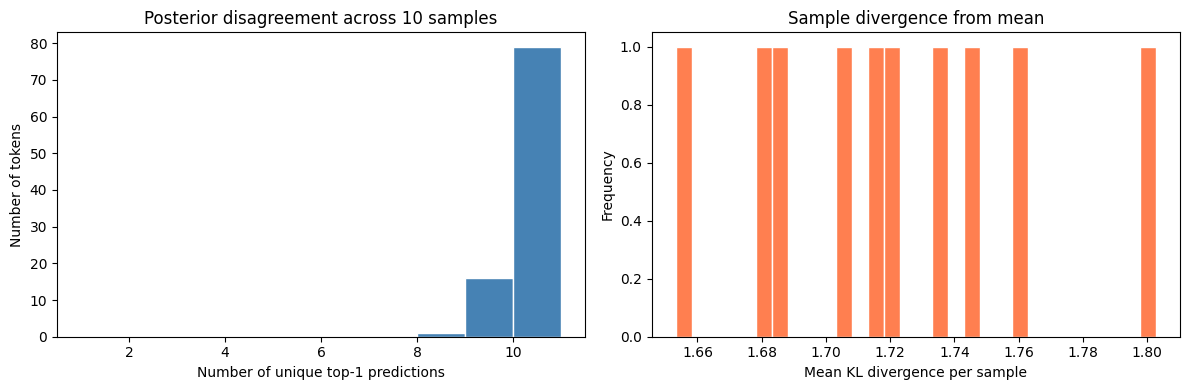

In [58]:
# Sample from the posterior and collect token distributions
n_samples = 10
print(f"Drawing {n_samples} posterior samples and collecting token distributions...")

all_samples_probs = []  # list of (n_tokens, vocab_size) arrays

for i in range(n_samples):
    sample = sampler.sample(seed=i)
    sentence_dists = backend.score_posterior_sample(prepared, sample)
    # Concatenate token probs across all sentences
    token_probs = np.vstack([d.token_probabilities for d in sentence_dists])
    all_samples_probs.append(token_probs)

print(f"Collected {len(all_samples_probs)} samples, each with shape {all_samples_probs[0].shape}")

# Stack into (n_samples, n_tokens, vocab_size)
stacked_probs = np.stack(all_samples_probs, axis=0)
print(f"Stacked shape: {stacked_probs.shape}")

# Compute agreement: for each token, how often do the top-1 predictions agree?
top_1_predictions = np.argmax(all_samples_probs, axis=2)  # (n_samples, n_tokens)
print(f"\nTop-1 predictions shape: {top_1_predictions.shape}")

# For each token, count how many different top-1 predictions we get
diversity = []
for token_idx in range(top_1_predictions.shape[1]):
    preds_for_token = top_1_predictions[:, token_idx]
    num_unique = len(set(preds_for_token))
    diversity.append(num_unique)

print(f"\n=== Top-1 Prediction Diversity ===")
print(f"Tokens where top-1 predictions agree: {sum(1 for d in diversity if d == 1)} / {len(diversity)}")
print(f"Max number of different top-1 predictions for a single token: {max(diversity)}")
print(f"Average unique predictions per token: {np.mean(diversity):.2f}")

# Compute KL divergence between samples to quantify disagreement
mean_dist = np.mean(all_samples_probs, axis=0)  # predictive distribution
kl_divs = []  # KL(sample || mean)

for sample_probs in all_samples_probs:
    kl = np.sum(sample_probs * (np.log(sample_probs + 1e-10) - np.log(mean_dist + 1e-10)), axis=1)
    kl_divs.append(kl)

kl_divs = np.array(kl_divs)
print(f"\n=== KL Divergence from Mean ===")
print(f"Mean KL (per token, averaged): {np.mean(kl_divs):.4f}")
print(f"Max KL (per token): {np.max(kl_divs):.4f}")

# Plot: histogram of how much samples disagree
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(diversity, bins=range(1, max(diversity) + 2), color="steelblue", edgecolor="white", linewidth=1)
axes[0].set_xlabel("Number of unique top-1 predictions")
axes[0].set_ylabel("Number of tokens")
axes[0].set_title(f"Posterior disagreement across {n_samples} samples")

axes[1].hist(np.mean(kl_divs, axis=1), bins=30, color="coral", edgecolor="white", linewidth=1)
axes[1].set_xlabel("Mean KL divergence per sample")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Sample divergence from mean")

plt.tight_layout()
plt.show()

## 4. Uncertainty Distribution vs. Normalization


Quantile boundaries: ['1.2227', '1.2741', '1.2863', '1.2979', '1.3526']


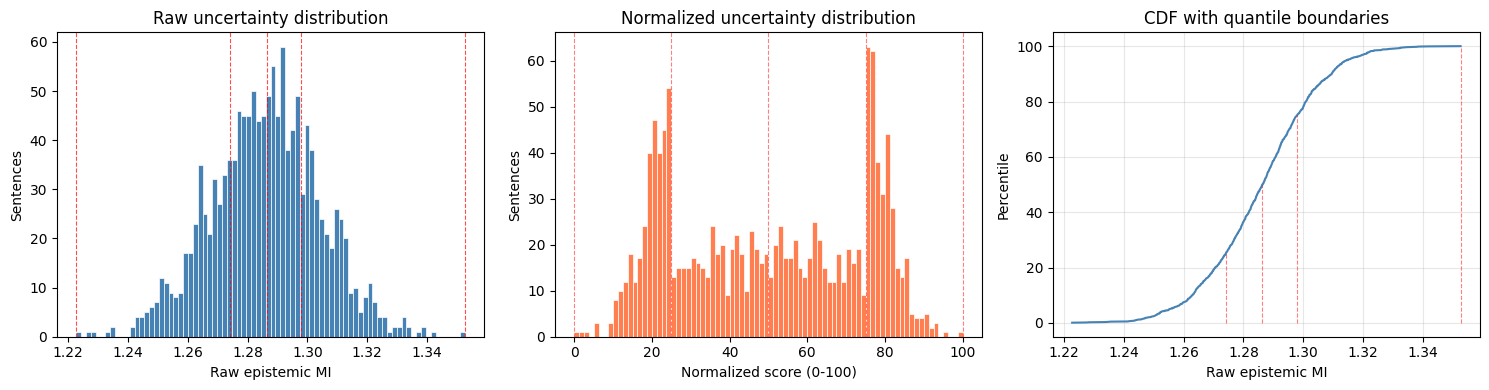


=== Normalized Score Statistics ===
Min:    0.0
25th:   25.0
Median: 50.0
75th:   75.0
Max:    100.0


In [59]:
from src.normalization import load_quantile_normalizer

# Load quantile normalizer
normalizer = load_quantile_normalizer(str(QUANTILES_FILE))
print(f"Quantile boundaries: {[f'{b:.4f}' for b in normalizer.boundaries]}")

# Normalize all raw scores
normalized_scores = [normalizer.normalize(score) for score in raw_uncertainties]

# Compare raw vs normalized distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(raw_uncertainties, bins=80, color="steelblue", edgecolor="white", linewidth=0.5)
for q, b in zip(["0%", "25%", "50%", "75%", "100%"], normalizer.boundaries):
    axes[0].axvline(b, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
axes[0].set_xlabel("Raw epistemic MI")
axes[0].set_ylabel("Sentences")
axes[0].set_title("Raw uncertainty distribution")

axes[1].hist(normalized_scores, bins=80, color="coral", edgecolor="white", linewidth=0.5)
for quantile_pos in [0, 25, 50, 75, 100]:
    axes[1].axvline(quantile_pos, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
axes[1].set_xlabel("Normalized score (0-100)")
axes[1].set_ylabel("Sentences")
axes[1].set_title("Normalized uncertainty distribution")

# CDF
sorted_raw = np.sort(raw_uncertainties)
cdf_y = np.arange(1, len(sorted_raw) + 1) / len(sorted_raw)
axes[2].plot(sorted_raw, cdf_y * 100, color="steelblue", linewidth=1.5, label="Raw uncertainty CDF")
for i, b in enumerate(normalizer.boundaries):
    y = i * 100 / (len(normalizer.boundaries) - 1)
    axes[2].plot([b, b], [0, y], color="red", linestyle="--", linewidth=0.8, alpha=0.5)
axes[2].set_xlabel("Raw epistemic MI")
axes[2].set_ylabel("Percentile")
axes[2].set_title("CDF with quantile boundaries")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== Normalized Score Statistics ===")
print(f"Min:    {np.min(normalized_scores):.1f}")
print(f"25th:   {np.percentile(normalized_scores, 25):.1f}")
print(f"Median: {np.median(normalized_scores):.1f}")
print(f"75th:   {np.percentile(normalized_scores, 75):.1f}")
print(f"Max:    {np.max(normalized_scores):.1f}")

## 5. High vs Low Uncertainty Examples


In [60]:
# Add normalized scores to dataframe
df["uncertainty_normalized"] = normalized_scores

# Sort by uncertainty
df_sorted = df.sort_values("uncertainty", ascending=False)

# High uncertainty examples
print("\n=== TOP 5 HIGHEST UNCERTAINTY SENTENCES ===")
for idx, row in df_sorted.head(5).iterrows():
    text = row["sentence_text"][:100] if len(row["sentence_text"]) > 100 else row["sentence_text"]
    print(f"\nRaw: {row['uncertainty']:.4f} | Normalized: {row['uncertainty_normalized']:.1f}")
    print(f"  Text: {text}")
    print(f"  Expected entropy: {row['expected_entropy']:.4f}")
    print(f"  Mean logprob: {row['mean_logprob']:.4f}")

# Low uncertainty examples
print("\n\n=== TOP 5 LOWEST UNCERTAINTY SENTENCES ===")
for idx, row in df_sorted.tail(5).iterrows():
    text = row["sentence_text"][:100] if len(row["sentence_text"]) > 100 else row["sentence_text"]
    print(f"\nRaw: {row['uncertainty']:.4f} | Normalized: {row['uncertainty_normalized']:.1f}")
    print(f"  Text: {text}")
    print(f"  Expected entropy: {row['expected_entropy']:.4f}")
    print(f"  Mean logprob: {row['mean_logprob']:.4f}")


=== TOP 5 HIGHEST UNCERTAINTY SENTENCES ===

Raw: 1.3526 | Normalized: 100.0
  Text: Research predominantly uses mouse and human embryonic stem cells, which share essential characterist
  Expected entropy: 5.3144
  Mean logprob: -17.1163

Raw: 1.3418 | Normalized: 95.1
  Text: So, there's this ongoing debate among scholars about how the plague really spread, and no one theory
  Expected entropy: 5.4762
  Mean logprob: -17.7718

Raw: 1.3383 | Normalized: 93.5
  Text: Research by British scholars Richard G. Wilkinson and Kate Pickett indicates a correlation between h
  Expected entropy: 5.7345
  Mean logprob: -15.6509

Raw: 1.3381 | Normalized: 93.4
  Text: So, Mahayana Buddhism started small around the 1st century BCE, but grew thanks to the diverse influ
  Expected entropy: 5.5313
  Mean logprob: -18.3115

Raw: 1.3369 | Normalized: 92.8
  Text: Their findings suggest that societies with lower inequality tend to exhibit better health outcomes, 
  Expected entropy: 5.6165
  Mean logprob

## 6. Relationship Between Posterior Disagreement and Uncertainty


In [61]:
# For the test summary, check which sentences have highest epistemic MI
print("\n=== Sentences Ranked by Epistemic MI ===")
for sent in prepared.sentences:
    idx = sent.sentence_index
    matching = [s for s in all_sentence_scores if s["sentence_index"] == idx]
    if matching:
        score = matching[0]["uncertainty"]
        text = sent.text[:80]
        print(f"[{score:.4f}] {text}")


=== Sentences Ranked by Epistemic MI ===
[1.2700] The 16th-century advancements in timekeeping culminated in the invention of the 
[1.2826] This innovation significantly enhanced the precision of time measurement, leadin


## 7. Summary Report


In [62]:
print("\n" + "="*70)
print("VALIDATION SUMMARY")
print("="*70)

print(f"\n[LAPLACE FIT]")
print(f"  Posterior std mean: {float(posterior_std.mean()):.4f}")
print(f"  Meaningful variance (>1e-6): {len(non_tiny)} / {len(posterior_var)} params ({100*len(non_tiny)/len(posterior_var):.1f}%)")
status = "✓ HEALTHY" if len(non_tiny) > len(posterior_var) * 0.5 else "⚠ DEGENERATE"
print(f"  Status: {status}")

print(f"\n[POSTERIOR DISAGREEMENT]")
print(f"  Tokens with >1 unique top-1 predictions: {sum(1 for d in diversity if d > 1)} / {len(diversity)}")
print(f"  Mean KL divergence from mean: {np.mean(kl_divs):.4f}")
status = "✓ DIVERSE" if sum(1 for d in diversity if d > 1) > len(diversity) * 0.5 else "⚠ LOW DIVERSITY"
print(f"  Status: {status}")

print(f"\n[UNCERTAINTY DISTRIBUTION]")
print(f"  Raw score range: [{np.min(raw_uncertainties):.4f}, {np.max(raw_uncertainties):.4f}]")
print(f"  Normalized score range: [{np.min(normalized_scores):.1f}, {np.max(normalized_scores):.1f}]")
pct_below_10 = sum(1 for s in normalized_scores if s < 10) / len(normalized_scores) * 100
print(f"  Sentences with normalized score < 10: {pct_below_10:.1f}%")
status = "⚠ SKEWED" if pct_below_10 > 50 else "✓ BALANCED"
print(f"  Status: {status}")

print(f"\n[OVERALL]")
print(f"  Total sentences scored: {len(all_sentence_scores)}")
print(f"  Total summaries: {len(all_records)}")
print(f"")
print(f"Next steps:")
print(f"  1. If posterior disagreement is LOW: increase sample_count or check Laplace fit")
print(f"  2. If uncertainty is skewed: consider recalibrating quantile boundaries")
print(f"  3. Inspect high-uncertainty sentences to understand what triggers uncertainty")


VALIDATION SUMMARY

[LAPLACE FIT]
  Posterior std mean: 10.0000
  Meaningful variance (>1e-6): 98304 / 98304 params (100.0%)
  Status: ✓ HEALTHY

[POSTERIOR DISAGREEMENT]
  Tokens with >1 unique top-1 predictions: 96 / 96
  Mean KL divergence from mean: 1.7208
  Status: ✓ DIVERSE

[UNCERTAINTY DISTRIBUTION]
  Raw score range: [1.2227, 1.3526]
  Normalized score range: [0.0, 100.0]
  Sentences with normalized score < 10: 0.7%
  Status: ✓ BALANCED

[OVERALL]
  Total sentences scored: 1342
  Total summaries: 500

Next steps:
  1. If posterior disagreement is LOW: increase sample_count or check Laplace fit
  2. If uncertainty is skewed: consider recalibrating quantile boundaries
  3. Inspect high-uncertainty sentences to understand what triggers uncertainty
